## 2026 CVE Data

In [22]:
# Import necessary libraries
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown
from datetime import date
import calplot
import glob
import json
import logging
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import os
import subprocess

# Register a cell magic for Markdown
@register_cell_magic
def markdown(line, cell):
    return Markdown(cell.format(**globals()))

# Configure logging and warnings
logging.getLogger('matplotlib.font_manager').disabled = True
warnings.filterwarnings("ignore")

# Set pandas display options
pd.set_option('display.width', 500)
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 10)

# Set the path to the shared data file
data_path = '../data/nvd.jsonl'
if not os.path.exists(data_path):
    print(f"Data file not found at {data_path}. Attempting to download...")
    try:
        subprocess.run(['python', '../download_data.py'], check=True)
    except Exception as e:
        print(f"Download script failed: {e}")
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"Data file not found at {data_path} after attempting download. Please check your setup.")

In [23]:
def get_nested_value(entry, keys, default='Missing_Data'):
    try:
        for key in keys:
            entry = entry[key]
        return entry
    except (KeyError, IndexError):
        return default

row_accumulator = []
for filename in glob.glob(data_path):
    with open(filename, 'r', encoding='utf-8') as f:
        nvd_data = json.load(f)
        for entry in nvd_data:
            new_row = {
                'CVE': get_nested_value(entry, ['cve', 'id']),
                'Published': get_nested_value(entry, ['cve', 'published']),
                'AttackVector': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'attackVector']),
                'AttackComplexity': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'attackComplexity']),
                'PrivilegesRequired': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'privilegesRequired']),
                'UserInteraction': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'userInteraction']),
                'Scope': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'scope']),
                'ConfidentialityImpact': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'confidentialityImpact']),
                'IntegrityImpact': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'integrityImpact']),
                'AvailabilityImpact': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'availabilityImpact']),
                'BaseScore': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'baseScore'], '0.0'),
                'BaseSeverity': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'baseSeverity']),
                'ExploitabilityScore': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'exploitabilityScore']),
                'ImpactScore': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'impactScore']),
                'CWE': get_nested_value(entry, ['cve', 'weaknesses', 0, 'description', 0, 'value']),
                'Description': get_nested_value(entry, ['cve', 'descriptions', 0, 'value'], ''),
                'Assigner': get_nested_value(entry, ['cve', 'sourceIdentifier']),
                'Tag': get_nested_value(entry, ['cve', 'cveTags', 0, 'tags'], np.nan),
                'Status': get_nested_value(entry, ['cve', 'vulnStatus'], '')
            }
            row_accumulator.append(new_row)

nvd = pd.DataFrame(row_accumulator)
nvd = nvd[~nvd.Status.str.contains('Rejected')]
nvd['Published'] = pd.to_datetime(nvd['Published'])
thisyear = ((nvd['Published'] > '2026-01-01') & (nvd['Published']  < '2026-02-01'))
nvd = nvd.loc[thisyear]
nvd = nvd.sort_values(by=['Published'])
nvd = nvd.reset_index(drop=True)
nvd['BaseScore'] = pd.to_numeric(nvd['BaseScore']);
nvd['BaseScore'] = pd.to_numeric(nvd['BaseScore']);
nvd['BaseScore'] = nvd['BaseScore'].replace(0, np.nan);
nvdcount = nvd['Published'].count()
nvdunique = nvd['Published'].nunique()
startdate = date(2026, 1, 1)
enddate  = date(2026, 12, 1)
numberofdays = enddate - startdate 
per_day = nvdcount/numberofdays.days


In [24]:
Markdown(f"Total Number of CVEs: **{nvd['CVE'].count()}**<br />Average CVEs Per Day: **{per_day.round(2)}**<br />Average CVSS Score: **{nvd['BaseScore'].mean().round(2)}**")

Total Number of CVEs: **4319**<br />Average CVEs Per Day: **12.93**<br />Average CVSS Score: **6.89**

In [25]:
Markdown(f"## CVE Graphs")

## CVE Graphs

In [26]:
Month_Graph = nvd['Published'].groupby(nvd.Published.dt.to_period("M")).agg('count')
Year_Graph = nvd['Published'].groupby(nvd.Published.dt.to_period("Y")).agg('count')
Week_Graph = nvd['Published'].groupby(nvd.Published.dt.to_period("W")).agg('count')
Day_Graph = nvd['Published'].groupby(nvd.Published.dt.to_period("D")).agg('count')

In [27]:
Markdown(f"### CVE Calendar")

### CVE Calendar

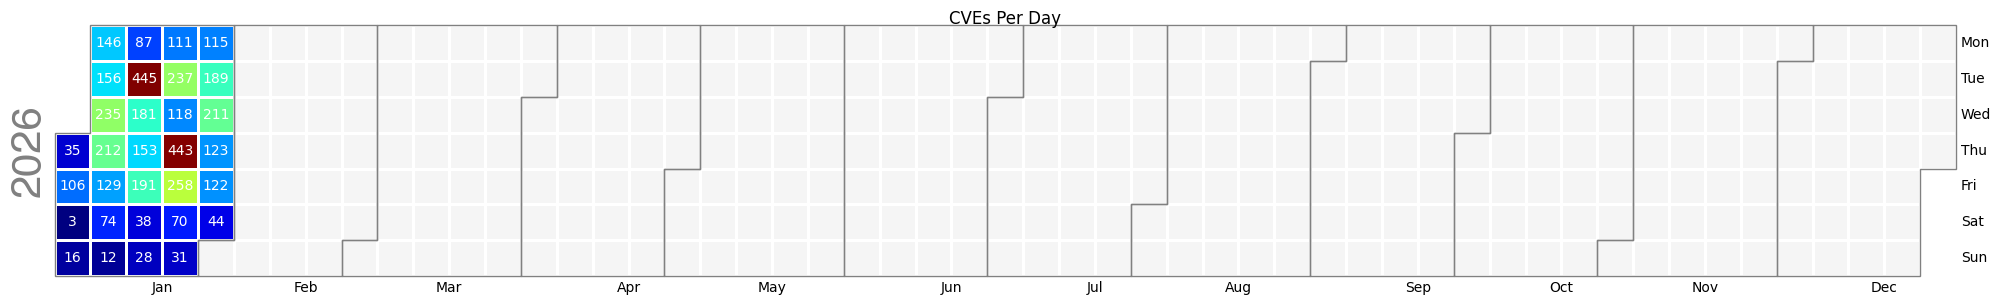

In [28]:
dfs = nvd['Published'].apply(lambda x: pd.to_datetime(x, errors='coerce', format='%Y/%m/%d'))
df = dfs.value_counts()
df = df.to_frame()
df.index = df.index.strftime('%m/%d/%Y')
df.index = pd.to_datetime(df.index, format='%m/%d/%Y')
calplot.calplot(df.T.squeeze(), cmap='jet', dropzero=True, edgecolor="Grey", textcolor="White", textformat='{:.0f}', textfiller='', suptitle='CVEs Per Day', figsize=(25,3));

#### Per Month

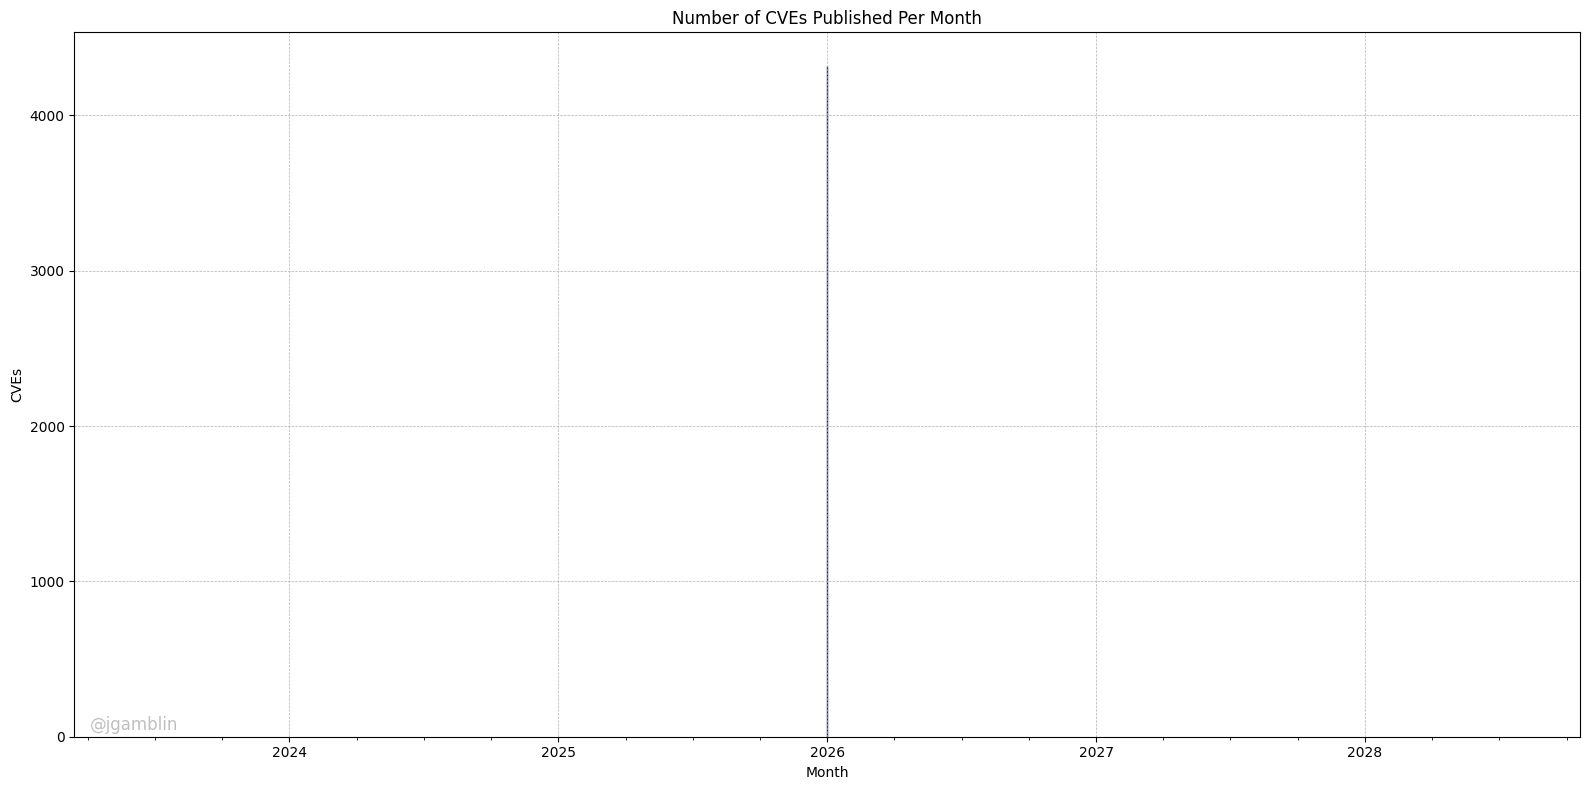

In [29]:
cg = Month_Graph.plot.area(colormap='cividis', figsize=(16, 8), title='Number of CVEs Published Per Month')
plt.grid(True, linestyle='--', linewidth=0.5)
cg.set_ylabel("CVEs")
cg.set_xlabel("Month")

# Add watermark
plt.text(0.01, 0.01, '@jgamblin', transform=cg.transAxes, fontsize=12, color='gray', alpha=0.5)

# Adjust layout and save the chart as a PNG file one directory up
plt.tight_layout()
plt.show()

In [30]:
Markdown(f"### CVE Per Week Graph")

### CVE Per Week Graph

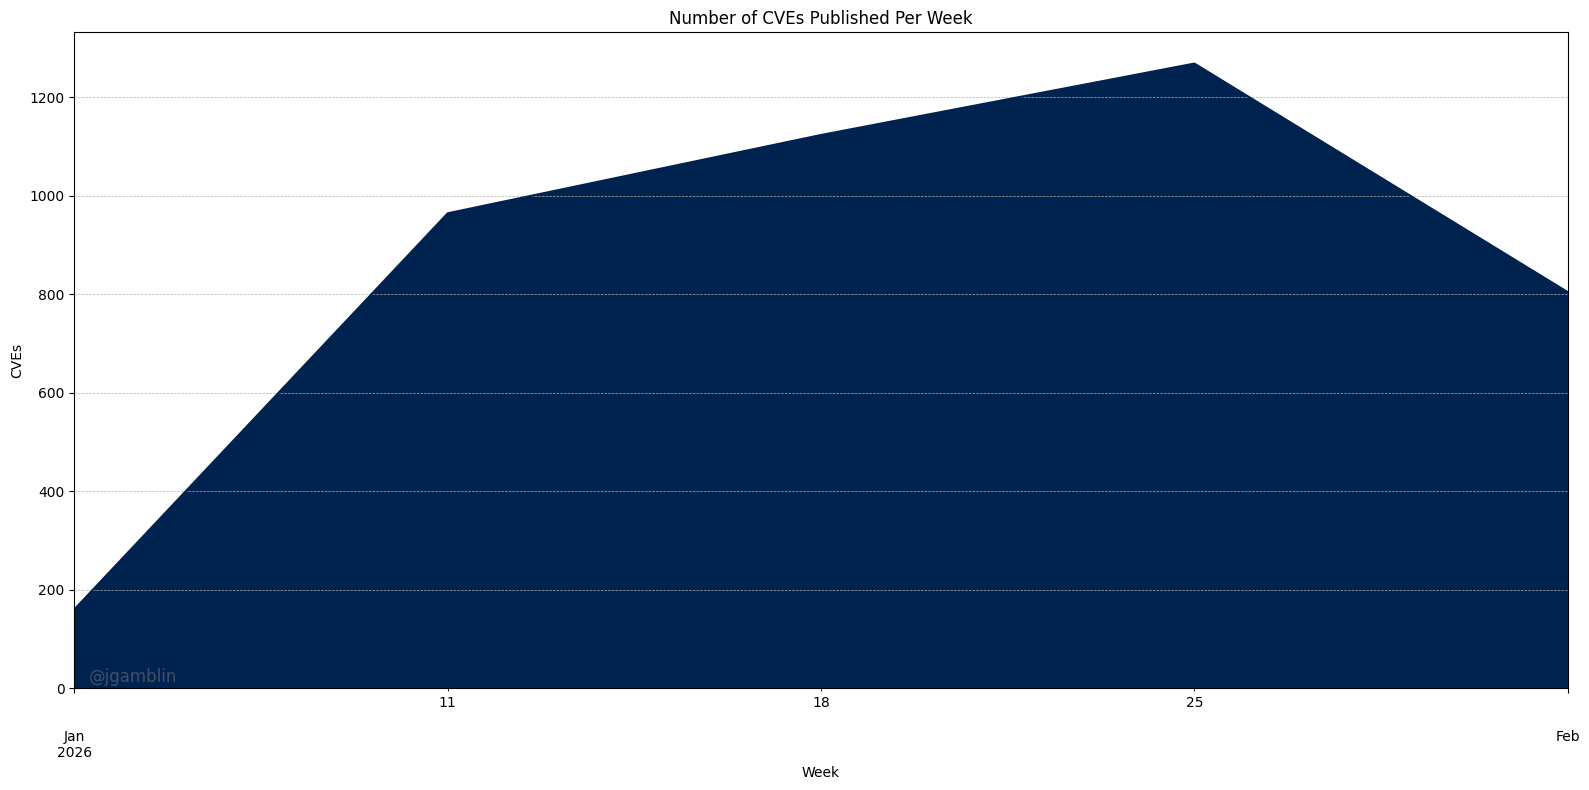

In [31]:
cg = Week_Graph.plot.area(colormap='cividis', figsize=(16, 8), title='Number of CVEs Published Per Week')
plt.grid(True, linestyle='--', linewidth=0.5)
cg.set_ylabel("CVEs")
cg.set_xlabel("Week")

# Add watermark
plt.text(0.01, 0.01, '@jgamblin', transform=cg.transAxes, fontsize=12, color='gray', alpha=0.5)

# Adjust layout and save the chart as a PNG file one directory up
plt.tight_layout()

plt.show()

In [32]:
Markdown(f"### CVE Per Day Graph")

### CVE Per Day Graph

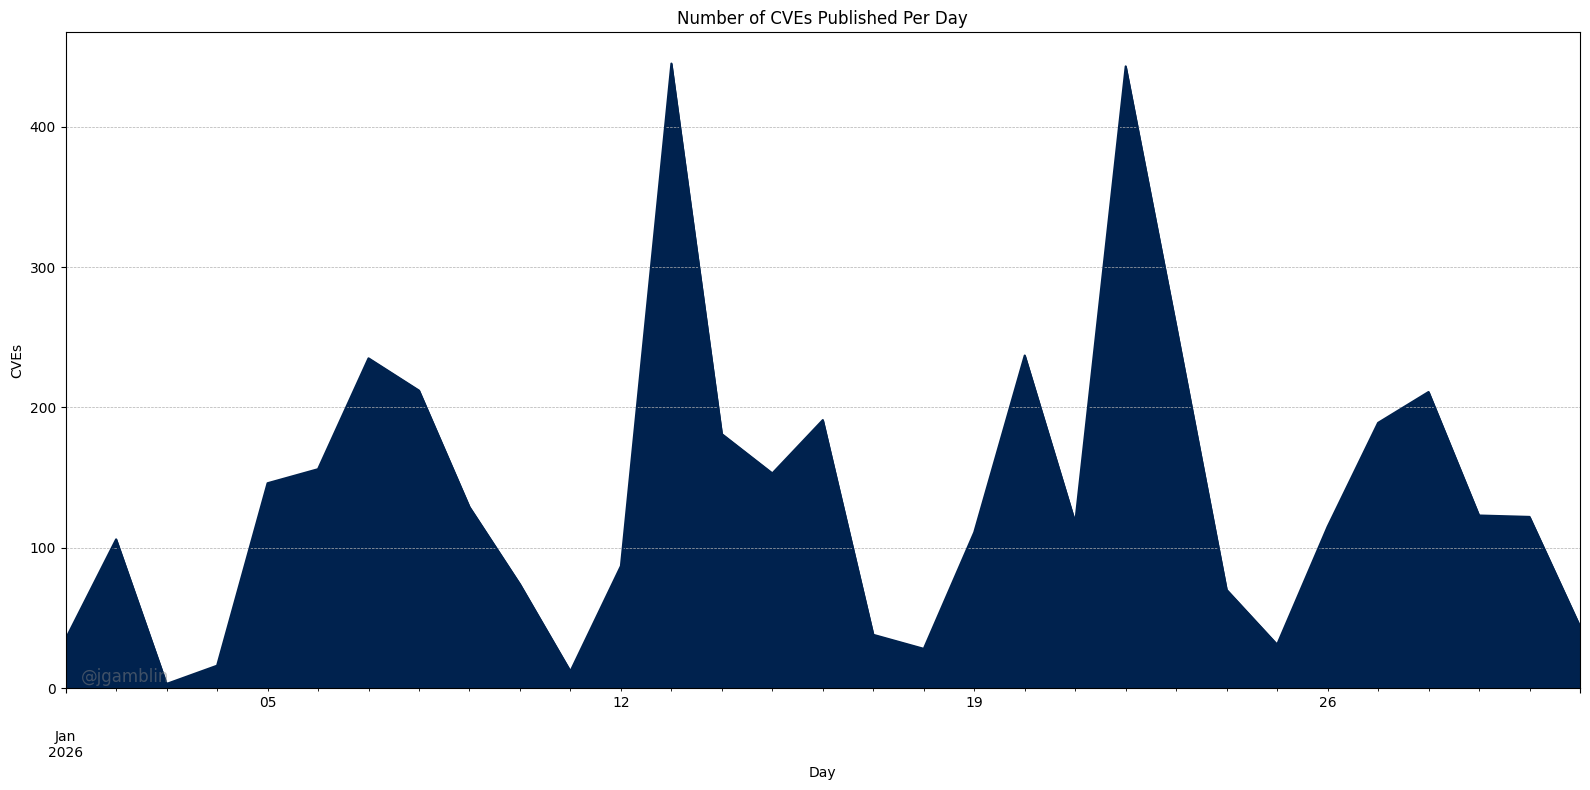

In [33]:
cg = Day_Graph.plot.area(colormap='cividis', figsize=(16, 8), title='Number of CVEs Published Per Day')
plt.grid(True, linestyle='--', linewidth=0.5)
cg.set_ylabel("CVEs")
cg.set_xlabel("Day")

# Add watermark
plt.text(0.01, 0.01, '@jgamblin', transform=cg.transAxes, fontsize=12, color='gray', alpha=0.5)

# Adjust layout and show the chart
plt.tight_layout()
plt.show()

In [34]:
Markdown(f"## CVSS Data")

## CVSS Data

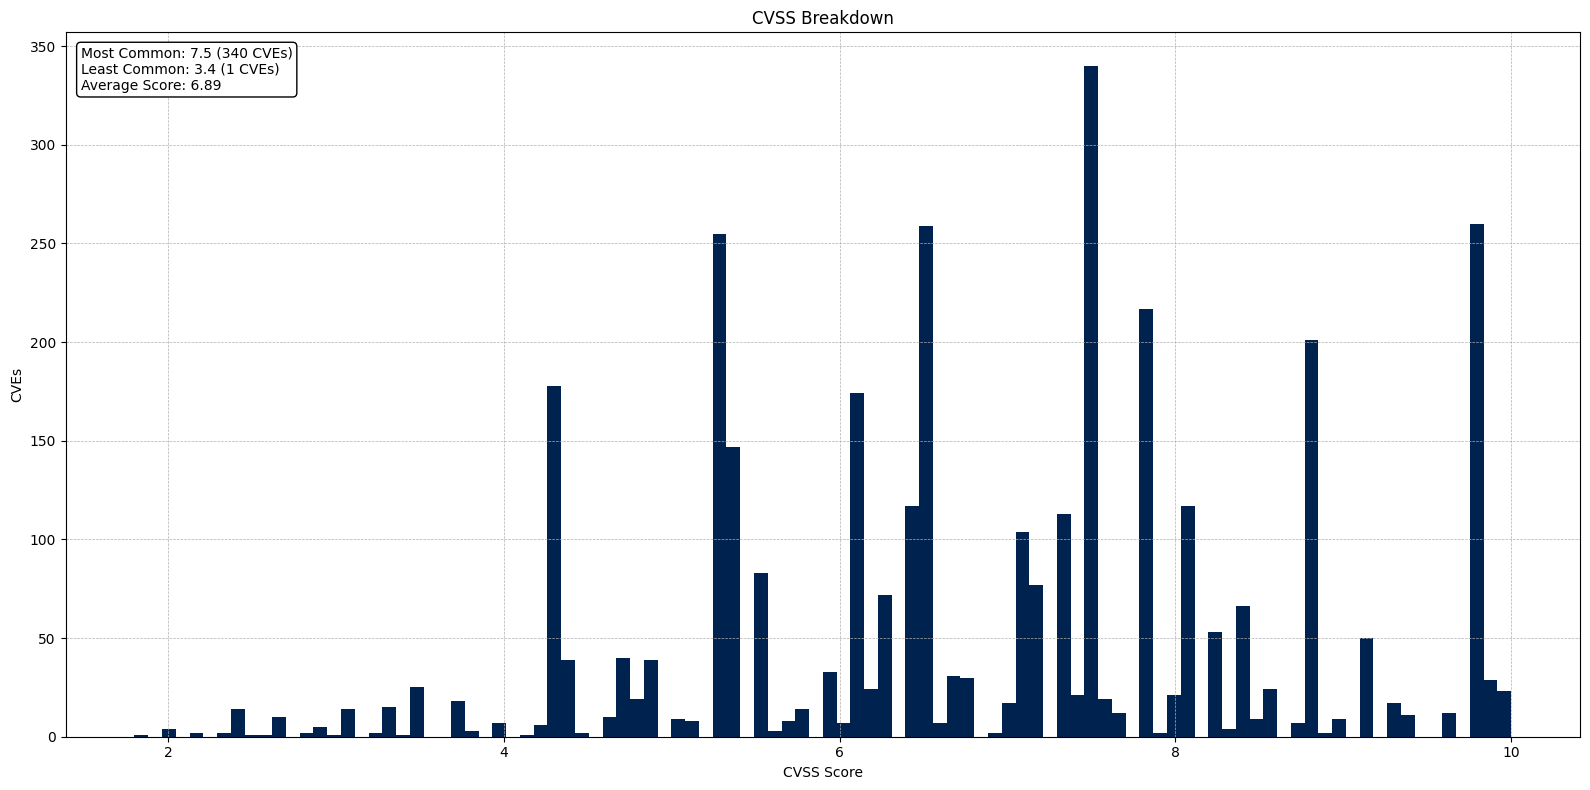

In [35]:
nvd['BaseScore'] = pd.to_numeric(nvd['BaseScore'])
nvd['BaseScore'] = nvd['BaseScore'].replace(0, np.nan)

# Plot the CVSS breakdown with 100 bins
cg = nvd['BaseScore'].plot(kind="hist", bins=100, title='CVSS Breakdown', colormap='cividis', figsize=(16, 8))
plt.grid(True, linestyle='--', linewidth=0.5)
cg.set_ylabel("CVEs")
cg.set_xlabel("CVSS Score")

# Find the most common, least common, and average CVSS scores
most_common_score = nvd['BaseScore'].mode()[0]
least_common_score = nvd['BaseScore'].value_counts().idxmin()
most_common_count = nvd['BaseScore'].value_counts().max()
least_common_count = nvd['BaseScore'].value_counts().min()
average_score = nvd['BaseScore'].mean().round(2)

# Add annotation for the most common, least common, and average CVSS scores
annotation_text = (f'Most Common: {most_common_score} ({most_common_count} CVEs)\n'
                   f'Least Common: {least_common_score} ({least_common_count} CVEs)\n'
                   f'Average Score: {average_score}')
plt.text(0.01, 0.98, annotation_text, transform=cg.transAxes, fontsize=10, color='black',
         verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='white'))

# Adjust layout and save the chart as a PNG file one directory up
plt.tight_layout()
plt.show()

In [36]:
Markdown(f"## CNA Data")

## CNA Data

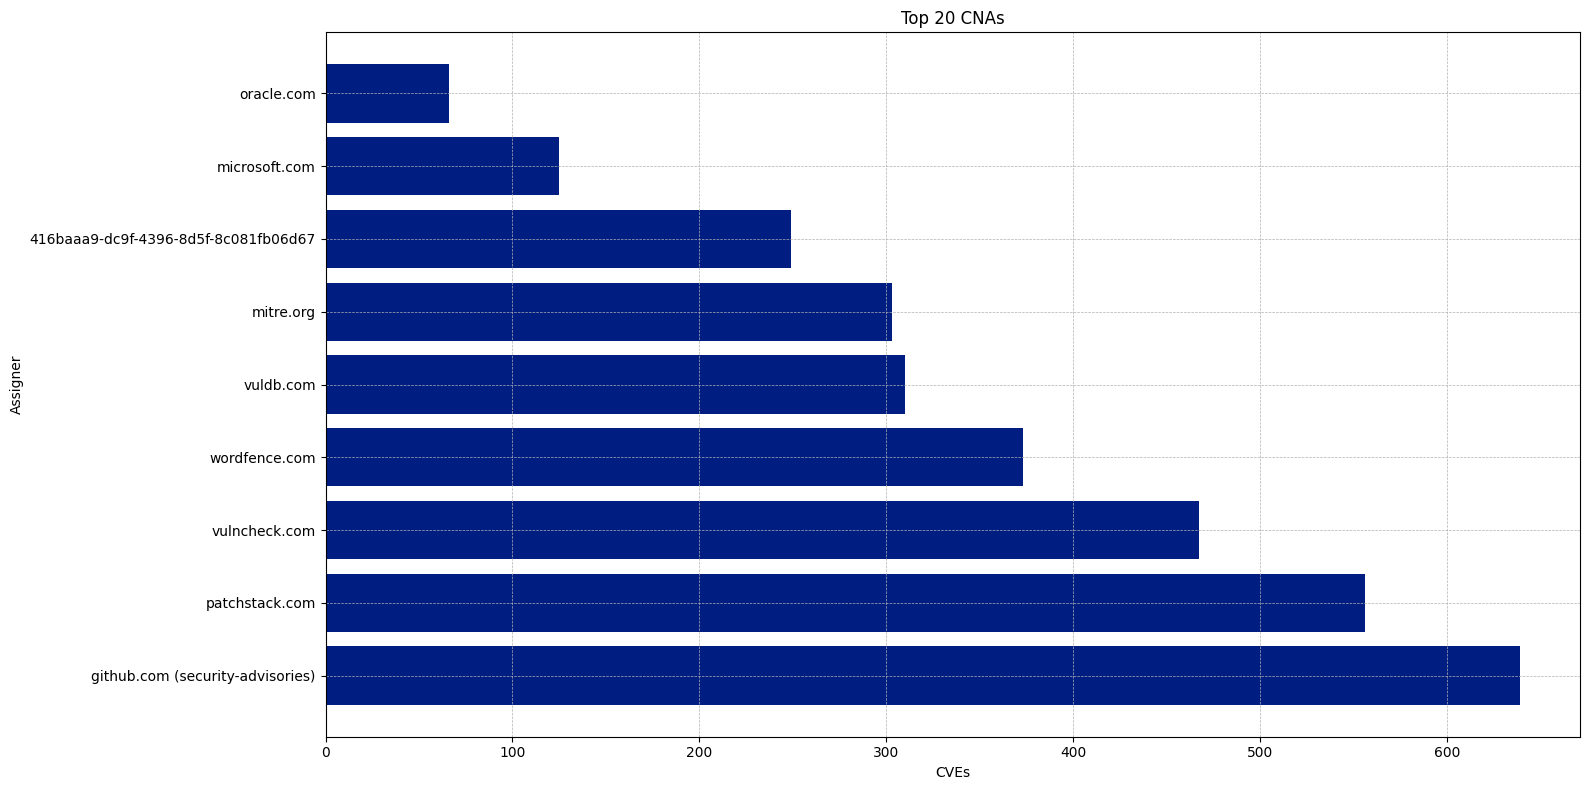

In [37]:
import matplotlib.pyplot as plt

# Replace specific assigner ID with email
nvd['Assigner'].replace('416baaa9-dc9f-4396-8d5f-8c081fb06d67', 'cve@kernel.org', inplace=True)

# Extract domain names and check for uniqueness
nvd['Domain'] = nvd['Assigner'].apply(lambda x: x.split('@')[-1])
domain_counts = nvd['Domain'].value_counts()

# Modify Assigner column based on domain uniqueness
unique_domains = nvd.groupby('Domain')['Assigner'].nunique()
nvd['Assigner'] = nvd.apply(lambda x: x['Domain'] if unique_domains[x['Domain']] == 1 else f"{x['Domain']} ({x['Assigner'].split('@')[0]})", axis=1)

# Calculate frequency of assigners
nvd_frequency = nvd['Assigner'].value_counts().reset_index()
nvd_frequency.columns = ['Assigner', 'counts']
nvd_frequency = nvd_frequency[nvd_frequency.counts > 50].head(50)

# Plot the top 20 CNAs
plt.figure(figsize=(16, 8))
plt.barh("Assigner", "counts", data=nvd_frequency, color="#001d82")
plt.xlabel("CVEs")
plt.ylabel("Assigner")
plt.title("Top 20 CNAs")
plt.grid(True, linestyle='--', linewidth=0.5)

# Adjust layout and show the chart
plt.tight_layout()
plt.show()

In [38]:
Markdown(f"## CWE Data")

## CWE Data

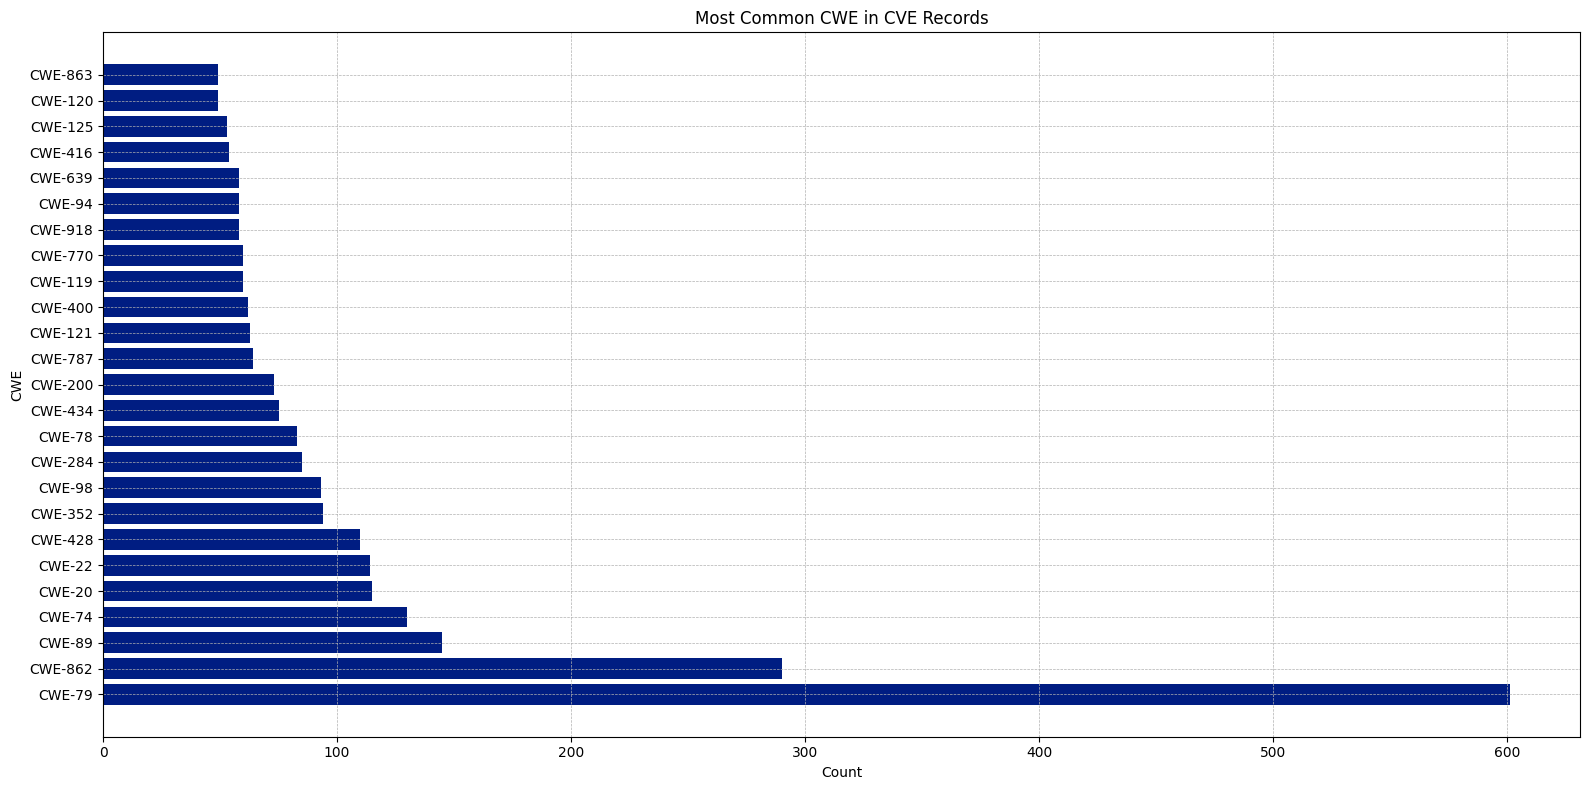

In [39]:
import matplotlib.pyplot as plt

# Calculate frequency of CWEs
nvd_cwe = nvd['CWE'].value_counts().reset_index()
nvd_cwe.columns = ['CWE', 'counts']
nvd_cwe = nvd_cwe[~nvd_cwe.CWE.str.contains('Missing_')]
nvd_cwe = nvd_cwe[nvd_cwe.counts > 20].head(25)

# Plot the most common CWEs
plt.figure(figsize=(16, 8))
plt.barh(nvd_cwe['CWE'], nvd_cwe['counts'], color="#001d82")
plt.xlabel("Count")
plt.ylabel("CWE")
plt.title("Most Common CWE in CVE Records")
plt.grid(True, linestyle='--', linewidth=0.5)

# Adjust layout and show the chart
plt.tight_layout()
plt.show()

In [40]:
Markdown(f"## More CVE Data")

## More CVE Data

In [41]:
Markdown(f"### Top CNA Assigner")

### Top CNA Assigner

In [43]:
nvd_frequency.style.hide()

Assigner,counts
github.com (security-advisories),639
patchstack.com,556
vulncheck.com,467
wordfence.com,373
vuldb.com,310
mitre.org,303
416baaa9-dc9f-4396-8d5f-8c081fb06d67,249
microsoft.com,125
oracle.com,66


In [44]:
Markdown(f"### CVEs By Identifier")

### CVEs By Identifier

In [45]:
years = range(1999, 2026)
cve_counts = []

for year in years:
    count = len(nvd[nvd['CVE'].str.contains(f'CVE-{year}-')])
    if count > 0:
        cve_counts.append({'Year': year, 'Count': count})

cve_df = pd.DataFrame(cve_counts)
cve_df.style.hide(axis='index')

Year,Count
2011,1
2012,1
2016,1
2017,5
2018,2
2019,17
2020,152
2021,156
2022,55
2023,25


In [46]:
Markdown(f"### First 5 CVEs")

### First 5 CVEs

In [47]:
nvd[["CVE", "Description"]].head(5).style.hide()

CVE,Description
CVE-2025-69412,"KDE messagelib before 25.11.90 ignores SSL errors for threatMatches:find in the Google Safe Browsing Lookup API (aka phishing API), which might allow spoofing of threat data. NOTE: this Lookup API is not contacted in the messagelib default configuration."
CVE-2025-69413,"In Gitea before 1.25.2, /api/v1/user has different responses for failed authentication depending on whether a username exists."
CVE-2025-13820,"The Comments WordPress plugin before 7.6.40 does not properly validate user's identity when using the disqus.com provider, allowing an attacker to log in to any user (when knowing their email address) when such user does not have an account on disqus.com yet."
CVE-2025-11157,"A high-severity remote code execution vulnerability exists in feast-dev/feast version 0.53.0, specifically in the Kubernetes materializer job located at `feast/sdk/python/feast/infra/compute_engines/kubernetes/main.py`. The vulnerability arises from the use of `yaml.load(..., Loader=yaml.Loader)` to deserialize `/var/feast/feature_store.yaml` and `/var/feast/materialization_config.yaml`. This method allows for the instantiation of arbitrary Python objects, enabling an attacker with the ability to modify these YAML files to execute OS commands on the worker pod. This vulnerability can be exploited before the configuration is validated, potentially leading to cluster takeover, data poisoning, and supply-chain sabotage."
CVE-2026-0544,A security flaw has been discovered in itsourcecode School Management System 1.0. This affects an unknown part of the file /student/index.php. The manipulation of the argument ID results in sql injection. It is possible to launch the attack remotely. The exploit has been released to the public and may be used for attacks.


In [48]:
Markdown(f"### Last 5 CVEs")

### Last 5 CVEs

In [49]:

nvd[["CVE", "Description"]].tail(5).style.hide()

CVE,Description
CVE-2026-23037,"In the Linux kernel, the following vulnerability has been resolved: can: etas_es58x: allow partial RX URB allocation to succeed When es58x_alloc_rx_urbs() fails to allocate the requested number of URBs but succeeds in allocating some, it returns an error code. This causes es58x_open() to return early, skipping the cleanup label 'free_urbs', which leads to the anchored URBs being leaked. As pointed out by maintainer Vincent Mailhol, the driver is designed to handle partial URB allocation gracefully. Therefore, partial allocation should not be treated as a fatal error. Modify es58x_alloc_rx_urbs() to return 0 if at least one URB has been allocated, restoring the intended behavior and preventing the leak in es58x_open()."
CVE-2026-23038,"In the Linux kernel, the following vulnerability has been resolved: pnfs/flexfiles: Fix memory leak in nfs4_ff_alloc_deviceid_node() In nfs4_ff_alloc_deviceid_node(), if the allocation for ds_versions fails, the function jumps to the out_scratch label without freeing the already allocated dsaddrs list, leading to a memory leak. Fix this by jumping to the out_err_drain_dsaddrs label, which properly frees the dsaddrs list before cleaning up other resources."
CVE-2026-23039,"In the Linux kernel, the following vulnerability has been resolved: drm/gud: fix NULL fb and crtc dereferences on USB disconnect On disconnect drm_atomic_helper_disable_all() is called which sets both the fb and crtc for a plane to NULL before invoking a commit. This causes a kernel oops on every display disconnect. Add guards for those dereferences."
CVE-2025-14554,"The Sell BTC - Cryptocurrency Selling Calculator plugin for WordPress is vulnerable to Stored Cross-Site Scripting via the 'orderform_data' AJAX action in all versions up to, and including, 1.5 due to insufficient input sanitization and output escaping. This makes it possible for unauthenticated attackers to inject arbitrary web scripts in order records that will execute whenever an administrator accesses the Orders page in the admin dashboard. The vulnerability was partially patched in version 1.5."
CVE-2026-1165,"The Popup Box plugin for WordPress is vulnerable to Cross-Site Request Forgery in all versions up to, and including, 6.1.1. This is due to a flawed nonce implementation in the 'publish_unpublish_popupbox' function that verifies a self-created nonce rather than one submitted in the request. This makes it possible for unauthenticated attackers to change the publish status of popups via a forged request, granted they can trick a site administrator into performing an action such as clicking a link."
